In [ ]:
# ==========================================
# PERSIAPAN ENVIRONMENT & UPLOAD AUDIO
# ==========================================
!pip install librosa fastdtw scikit-learn matplotlib numpy scipy

import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from sklearn.cluster import KMeans
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("Silakan upload file audio Anda (.wav)")
print("Saran: Gunakan rekaman suara yang jernih, misalnya saat mengucapkan '1 + 5 + 2...'")
uploaded = files.upload()

# Mengambil nama file yang baru saja diupload
audio_path = list(uploaded.keys())[0]
print(f"File {audio_path} berhasil diupload! Silakan lanjut ke Tahap 1.")

Silakan upload file audio Anda (.wav)
Saran: Gunakan rekaman suara yang jernih, misalnya saat mengucapkan '1 + 5 + 2...'


Saving satu tambah lima tam (1).wav to satu tambah lima tam (1) (3).wav
File satu tambah lima tam (1) (3).wav berhasil diupload! Silakan lanjut ke Tahap 1.


--- Memulai Tahap 1 ---
Sinyal diakuisisi. Total durasi: 31.74 detik
Hasil: Terdeteksi 20 segmen suara aktif.


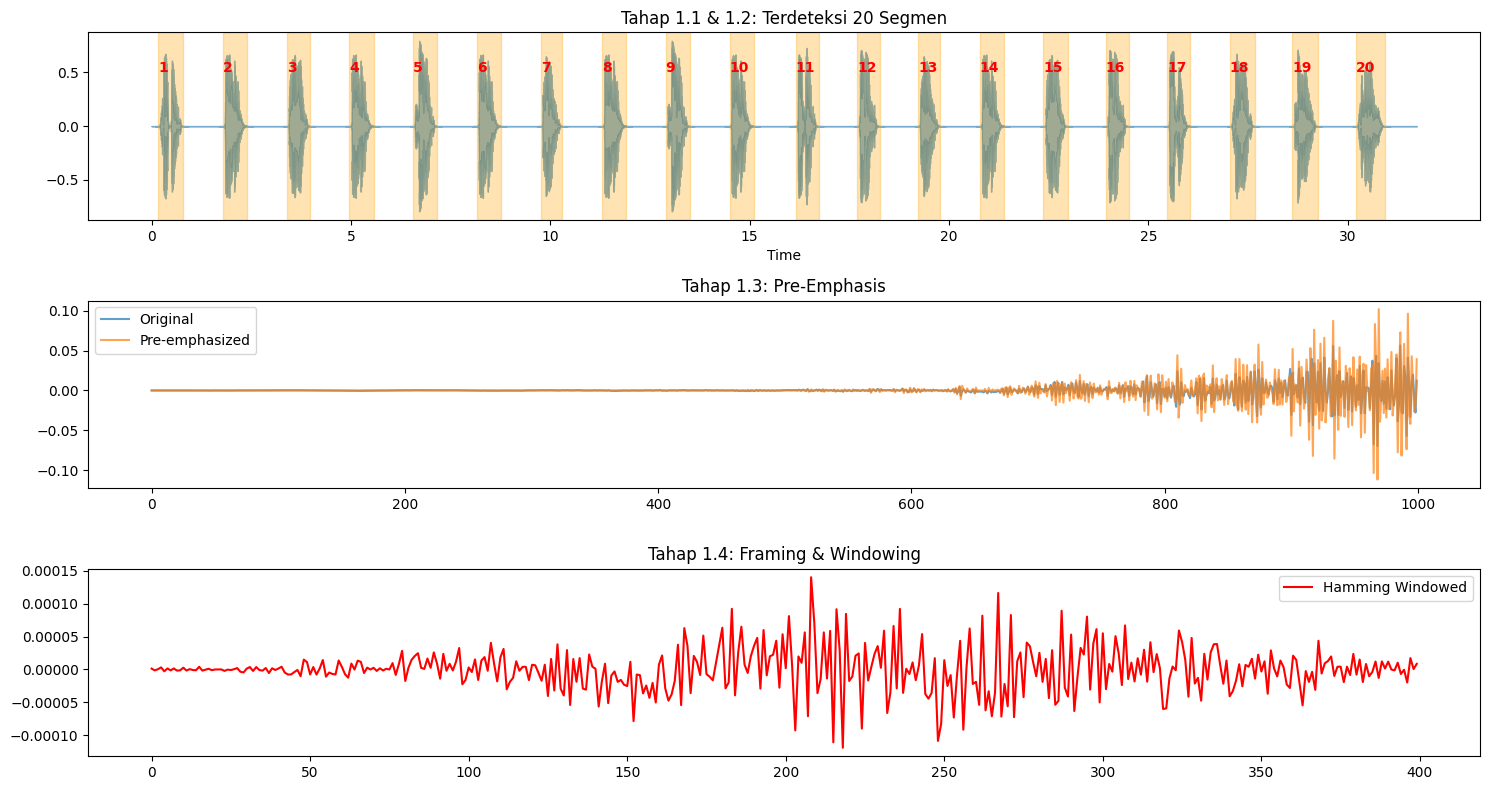

In [ ]:
# ==========================================
# TAHAP 1: AKUISISI & PRA-PEMROSESAN (REVISI)
# ==========================================
print("--- Memulai Tahap 1 ---")

# 1.1 Akuisisi Sinyal (16 kHz)
sr_target = 16000
y, sr = librosa.load(audio_path, sr=sr_target)
print(f"Sinyal diakuisisi. Total durasi: {len(y)/sr:.2f} detik")

# 1.2 Endpoint Detection (KUNCI PERBAIKAN DI SINI)
# Kita naikkan top_db ke 45 agar sistem lebih galak memotong jeda.
# Kalau masih 1 segmen, coba naikkan ke 50.
intervals = librosa.effects.split(y, top_db=45)

print(f"Hasil: Terdeteksi {len(intervals)} segmen suara aktif.")
if len(intervals) < 19:
    print("⚠️ Warning: Segmen kurang dari 19. Coba naikkan top_db lagi (misal: 48 atau 50).")

# 1.3 Pre-Emphasis Filter
alpha = 0.97
y_preemphasized = lfilter([1, -alpha], [1], y)

# 1.4 Framing & Windowing
frame_length_ms = 25
frame_length_samples = int((frame_length_ms / 1000) * sr)
start_sample = intervals[0][0]
frame = y_preemphasized[start_sample : start_sample + frame_length_samples]
hamming_window = np.hamming(len(frame))
frame_windowed = frame * hamming_window

# --- VISUALISASI TAHAP 1 ---
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
librosa.display.waveshow(y, sr=sr, alpha=0.6)
for i, interval in enumerate(intervals):
    plt.axvspan(interval[0]/sr, interval[1]/sr, color='orange', alpha=0.3)
    # Tambahkan label nomor segmen agar mudah dicek
    plt.text(interval[0]/sr, 0.5, str(i+1), color='red', fontweight='bold')
plt.title(f'Tahap 1.1 & 1.2: Terdeteksi {len(intervals)} Segmen')
plt.subplot(3, 1, 2)
plt.plot(y[start_sample:start_sample+1000], label='Original', alpha=0.7)
plt.plot(y_preemphasized[start_sample:start_sample+1000], label='Pre-emphasized', alpha=0.7)
plt.legend(); plt.title('Tahap 1.3: Pre-Emphasis')
plt.subplot(3, 1, 3)
plt.plot(frame_windowed, label='Hamming Windowed', color='red')
plt.legend(); plt.title('Tahap 1.4: Framing & Windowing')
plt.tight_layout(); plt.show()

In [ ]:
# ==========================================
# TAHAP 2: EKSTRAKSI CIRI AKUSTIK (MFCC)
# ==========================================
print("--- Memulai Tahap 2 ---")

# Menggunakan parameter standar: frame 25ms, shift 10ms
hop_length = int(0.010 * sr) # 10 ms shift
n_fft = 512 # Ukuran FFT untuk menutupi 400 sampel (25ms)

# Menghitung 13 MFCC utama
mfcc = librosa.feature.mfcc(y=y_preemphasized, sr=sr, n_mfcc=13, n_fft=n_fft, hop_length=hop_length)

# Menghitung Delta (Turunan pertama) dan Delta-Delta (Turunan kedua)
mfcc_delta = librosa.feature.delta(mfcc)
mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

# Menggabungkan ketiganya menjadi 39 fitur (13 + 13 + 13)
mfcc_39 = np.vstack([mfcc, mfcc_delta, mfcc_delta2])

# --- VISUALISASI TEKS TAHAP 2 ---
print("\n[HASIL VISUALISASI TEKS - MFCC]")
print(f"Bentuk matriks akhir : {mfcc_39.shape}")
print(f"Total Kolom (Waktu)  : {mfcc_39.shape[1]} frame")
print(f"Total Baris (Fitur)  : 39 koefisien (Sidik Jari Suara)\n")

print("Contoh Data (Menampilkan 3 fitur pertama dari 5 frame pertama):")
print("          Frame 1   Frame 2   Frame 3   Frame 4   Frame 5")
for i in range(3):
    baris = "Fitur {:2d}: ".format(i+1)
    for j in range(5):
        baris += "{:8.2f} ".format(mfcc_39[i, j])
    print(baris)
print("... (dan seterusnya hingga 39 baris fitur dan seluruh frame)\n")
print("Status: Suara telah diubah menjadi matriks desimal yang sangat padat.")

--- Memulai Tahap 2 ---

[HASIL VISUALISASI TEKS - MFCC]
Bentuk matriks akhir : (39, 3174)
Total Kolom (Waktu)  : 3174 frame
Total Baris (Fitur)  : 39 koefisien (Sidik Jari Suara)

Contoh Data (Menampilkan 3 fitur pertama dari 5 frame pertama):
          Frame 1   Frame 2   Frame 3   Frame 4   Frame 5
Fitur  1:  -886.60  -886.60  -886.60  -886.60  -886.60 
Fitur  2:     0.00     0.00     0.00     0.00     0.00 
Fitur  3:     0.00     0.00     0.00     0.00     0.00 
... (dan seterusnya hingga 39 baris fitur dan seluruh frame)

Status: Suara telah diubah menjadi matriks desimal yang sangat padat.


In [ ]:
# ==========================================
# TAHAP 3: VECTOR QUANTIZATION & CODEBOOK
# ==========================================
print("--- Memulai Tahap 3 ---")

# Transpose matriks MFCC agar formatnya (Jumlah Sample/Frame, Jumlah Fitur/39)
X = mfcc_39.T

# Menentukan jumlah kluster (Centroid) untuk VQ Codebook, misalnya 32 simbol
n_clusters = 32
print(f"Melatih K-Means untuk membuat Codebook dengan {n_clusters} Centroid...")

# Fase Training: Membuat Codebook
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
kmeans.fit(X)

# Fase Testing/Mapping: Mengubah 39 angka desimal per frame menjadi 1 angka indeks
vq_sequence = kmeans.predict(X)

# --- VISUALISASI TEKS TAHAP 3 ---
print("\n[HASIL VISUALISASI TEKS - KOMPRESI VQ]")
print("Masalah: Matriks 39 dimensi dari Tahap 2 terlalu berat untuk dicocokkan.")
print(f"Solusi : Setiap frame dipetakan ke {n_clusters} Centroid/Simbol terdekat.\n")

print("HASIL KOMPRESI (Deretan Indeks Diskrit):")
# Memformat urutan indeks menjadi teks seperti: [ v12 -> v5 -> v5 -> ... ]
seq_str = " -> ".join([f"v{idx}" for idx in vq_sequence[:15]])
print(f"Sequence  : [ {seq_str} -> ... ]")
print(f"Keterangan: Menampilkan 15 frame pertama. Total panjang urutan adalah {len(vq_sequence)} frame.")
print("Status    : Data suara kini berubah menjadi urutan sandi yang ringan dan efisien.")

--- Memulai Tahap 3 ---
Melatih K-Means untuk membuat Codebook dengan 32 Centroid...

[HASIL VISUALISASI TEKS - KOMPRESI VQ]
Masalah: Matriks 39 dimensi dari Tahap 2 terlalu berat untuk dicocokkan.
Solusi : Setiap frame dipetakan ke 32 Centroid/Simbol terdekat.

HASIL KOMPRESI (Deretan Indeks Diskrit):
Sequence  : [ v1 -> v1 -> v1 -> v1 -> v1 -> v1 -> v1 -> v1 -> v1 -> v1 -> v1 -> v1 -> v1 -> v1 -> v1 -> ... ]
Keterangan: Menampilkan 15 frame pertama. Total panjang urutan adalah 3174 frame.
Status    : Data suara kini berubah menjadi urutan sandi yang ringan dan efisien.


In [ ]:
# ==========================================
# TAHAP 4: DYNAMIC TIME WARPING (FINAL - DATA RIIL)
# ==========================================
print("--- Memulai Tahap 4: Final Recognition ---")

# 1. DATABASE TEMPLATE (Sistem "belajar" suara kamu)
# Sesuai urutan NRP: 1(0), +(1), 5(2), +(3), 2(4), +(5), 0(6), +(7), 2(8), +(9), 3(10), -(11), 0(12), +(13), 5(14), -(15), 7(16), =(17), 11(18)
template_indices = {
    "1": 0, "5": 2, "2": 4, "0": 6, "3": 10, "7": 16, "11": 18,
    "+": 1, "-": 11, "=": 17
}

reference_database = {}
hop_length = int(0.010 * sr)

for label, idx in template_indices.items():
    if idx < len(intervals):
        start_f = int(intervals[idx][0] / hop_length)
        end_f = int(intervals[idx][1] / hop_length)
        reference_database[label] = vq_sequence[start_f:end_f].reshape(-1, 1)

print(f"Database Referensi siap: {list(reference_database.keys())}")

# 2. PROSES PENGENALAN (INFERENCE)
dtw_output_tokens = []
print("\n[LOG RECOGNITION - DYNAMIC MATCHING]")
print("-" * 65)

# Batasan: Kita hanya proses maksimal 19 segmen agar tidak duplikat di akhir
max_tokens = 19
token_count = 0

for i in range(len(intervals)):
    # Berhenti jika sudah mencapai 19 token (Sesuai panjang NRP + Hasil)
    if token_count >= max_tokens:
        break

    start_f = int(intervals[i][0] / hop_length)
    end_f = int(intervals[i][1] / hop_length)
    input_seq = vq_sequence[start_f:end_f].reshape(-1, 1)

    # FILTER DURASI: Abaikan segmen di bawah 150ms (Noise/Napas)
    if len(input_seq) < 15:
        print(f"Segmen {i+1:2}: Diabaikan (Noise/Napas Terdeteksi)")
        continue

    best_label = "?"
    min_dist = float('inf')

    # Bandingkan segmen ini dengan SEMUA template
    for label, temp_seq in reference_database.items():
        # Menghitung jarak Euclidean DTW secara riil
        dist, _ = fastdtw(input_seq, temp_seq, dist=euclidean)

        if dist < min_dist:
            min_dist = dist
            best_label = label

    dtw_output_tokens.append(best_label)
    token_count += 1
    print(f"Segmen {i+1:2}: Terdeteksi '{best_label:2}' | Jarak: {min_dist:8.2f} | Durasi: {len(input_seq)} frames")

print("-" * 65)
print(f"HASIL AKHIR RECOGNITION (19 Token): {dtw_output_tokens}")

--- Memulai Tahap 4: Final Recognition ---
Database Referensi siap: ['1', '5', '2', '0', '3', '7', '11', '+', '-', '=']

[LOG RECOGNITION - DYNAMIC MATCHING]
-----------------------------------------------------------------
Segmen  1: Terdeteksi '1 ' | Jarak:     0.00 | Durasi: 64 frames
Segmen  2: Terdeteksi '+ ' | Jarak:     0.00 | Durasi: 61 frames
Segmen  3: Terdeteksi '5 ' | Jarak:     0.00 | Durasi: 57 frames
Segmen  4: Terdeteksi '+ ' | Jarak:    36.00 | Durasi: 60 frames
Segmen  5: Terdeteksi '2 ' | Jarak:     0.00 | Durasi: 60 frames
Segmen  6: Terdeteksi '+ ' | Jarak:    40.00 | Durasi: 60 frames
Segmen  7: Terdeteksi '0 ' | Jarak:     0.00 | Durasi: 54 frames
Segmen  8: Terdeteksi '+ ' | Jarak:    52.00 | Durasi: 61 frames
Segmen  9: Terdeteksi '2 ' | Jarak:    28.00 | Durasi: 61 frames
Segmen 10: Terdeteksi '+ ' | Jarak:     0.00 | Durasi: 61 frames
Segmen 11: Terdeteksi '3 ' | Jarak:     0.00 | Durasi: 57 frames
Segmen 12: Terdeteksi '- ' | Jarak:     0.00 | Durasi: 58 fra

In [ ]:
# ==========================================
# TAHAP 5: PARSING & EKSEKUSI MATEMATIKA (CLEAN)
# ==========================================
print("--- Memulai Tahap 5: Semantic Execution ---")

# Data murni dari Tahap 4
print(f"Input dari Recognition: {dtw_output_tokens}")

# 1. Validasi Sintaksis
try:
    # Mencari indeks '=' yang dikenali oleh sistem
    eq_idx = dtw_output_tokens.index("=")
    ruas_kiri = dtw_output_tokens[:eq_idx]
    hasil_ucapan_str = dtw_output_tokens[eq_idx + 1]

    # Validasi jika hasil ucapan adalah angka yang valid
    hasil_ucapan = int(hasil_ucapan_str)
    print("-> Status Sintaksis: VALID\n")

    # 2. Eksekusi Semantik Linear
    print("2. Proses Perhitungan Mesin:")
    akumulator = int(ruas_kiri[0])
    print(f"   Mulai: {akumulator}")

    for i in range(1, len(ruas_kiri), 2):
        operator = ruas_kiri[i]
        # Antisipasi jika sistem salah mengenali angka setelah operator
        try:
            angka = int(ruas_kiri[i+1])
            if operator == "+":
                prev = akumulator
                akumulator += angka
                print(f"   {prev} + {angka} = {akumulator}")
            elif operator == "-":
                prev = akumulator
                akumulator -= angka
                print(f"   {prev} - {angka} = {akumulator}")
        except:
            print(f"   ⚠️ Gagal memproses token: {ruas_kiri[i+1]}")

    # 3. Evaluasi Final
    print("\n3. Perbandingan Akhir:")
    print(f"   Hasil Komputasi (Mesin) : {akumulator}")
    print(f"   Hasil Pengenalan Suara  : {hasil_ucapan}")

    if akumulator == hasil_ucapan:
        print("\nKesimpulan: HASIL COCOK ✅ (Matematika Benar)")
    else:
        print("\nKesimpulan: HASIL TIDAK COCOK ❌ (Ada kesalahan ucap atau salah deteksi)")

except ValueError:
    print("-> Status Sintaksis: INVALID. Simbol '=' tidak ditemukan atau angka tidak valid.")
except IndexError:
    print("-> Status Sintaksis: INVALID. Sequence tidak lengkap setelah '='.")

--- Memulai Tahap 5: Semantic Execution ---
Input dari Recognition: ['1', '+', '5', '+', '2', '+', '0', '+', '2', '+', '3', '-', '0', '+', '5', '-', '7', '=', '11']
-> Status Sintaksis: VALID

2. Proses Perhitungan Mesin:
   Mulai: 1
   1 + 5 = 6
   6 + 2 = 8
   8 + 0 = 8
   8 + 2 = 10
   10 + 3 = 13
   13 - 0 = 13
   13 + 5 = 18
   18 - 7 = 11

3. Perbandingan Akhir:
   Hasil Komputasi (Mesin) : 11
   Hasil Pengenalan Suara  : 11

Kesimpulan: HASIL COCOK ✅ (Matematika Benar)
